In [73]:
import pandas as pd
import numpy as np
import cooler
import pybedtools

In [74]:
### to load a cooler with a specific resolution use the following syntax:
clr_rbp1 = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/RBP1-MNase-R1-filtered.mcool::resolutions/10000")
clr_ctrl = cooler.Cooler("/usr/users/papantonis1/aman/microc_data/nadine_macro/ctrl-MNase-R1-filtered.mcool::resolutions/10000")

In [75]:
ctrl_bed = pybedtools.BedTool("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_ctrl.bedpe").sort()
eed_bed = pybedtools.BedTool("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_rbp1.bedpe").sort()

In [76]:
# loading the merged loops file
mega_loop_ctrl = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_ctrl.bedpe", sep="\t", header=None, names=["chr1", "start1", "end1", "chr2", "start2", "end2"])
mega_loop_rbp1 = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/megalooplist/mega_merged_loops_rbp1.bedpe", sep="\t", header=None, names=["chr1", "start1", "end1", "chr2", "start2", "end2"])

In [77]:
slop_distance = 5000

In [78]:
shared = ctrl_bed.pair_to_pair(eed_bed, type='both', slop=slop_distance, is_sorted=False)
shared.count()
# this is loops present in both ctrl and eed

7481

In [79]:
shared_df = shared.to_dataframe().iloc[:, :6]
shared_df.columns = ["chr1", "start1", "end1", "chr2", "start2", "end2"]
#shared_df

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/pybedtools/bedtool.py:3756: UserWarning: Default names for filetype bed are:
['chrom', 'start', 'end', 'name', 'score', 'strand', 'thickStart', 'thickEnd', 'itemRgb', 'blockCount', 'blockSizes', 'blockStarts']
but file has 16 fields; you can supply custom names with the `names` kwarg
  warn(


In [80]:
# droping duplicates
#shared_df = shared_df.drop_duplicates()
#ctrl_df = mega_loop_ctrl.drop_duplicates()

In [81]:
shared_df = shared_df.drop_duplicates(subset=["chr1", "start1", "end1", "chr2", "start2", "end2"])

In [82]:
shared_df

,chr1,start1,end1,chr2,start2,end2
0,chr1,1952500,1957500,chr1,2042500,2047500
1,chr1,2202500,2207500,chr1,2382500,2387500
2,chr1,2412500,2417500,chr1,2552500,2557500
3,chr1,3490000,3495000,chr1,3615000,3620000
4,chr1,3565000,3570000,chr1,3615000,3620000
...,...,...,...,...,...,...
7475,chrY,10992500,10997500,chrY,11722500,11727500
7476,chrY,11002500,11007500,chrY,11292500,11297500
7477,chrY,11522500,11527500,chrY,11712500,11717500
7478,chrY,11525000,11530000,chrY,11680000,11685000


In [83]:
# CTRL-only (lost)
ctrl_lost = mega_loop_ctrl.merge(shared_df, how="left", indicator=True)
ctrl_lost = ctrl_lost[ctrl_lost["_merge"] == "left_only"].drop(columns="_merge")

In [84]:
ctrl_lost

,chr1,start1,end1,chr2,start2,end2
0,chr1,3912500,3917500,chr1,4592500,4597500
2,chr1,5502500,5507500,chr1,5742500,5747500
3,chr1,5632500,5637500,chr1,5742500,5747500
4,chr1,5635000,5640000,chr1,5980000,5985000
5,chr1,6555000,6560000,chr1,6645000,6650000
...,...,...,...,...,...,...
19024,chrX,114462500,114467500,chrX,114602500,114607500
19026,chrX,132022500,132027500,chrX,132212500,132217500
19029,chrY,10820000,10825000,chrY,11290000,11295000
19032,chrY,11302500,11307500,chrY,11722500,11727500


In [85]:
# RBP1-only (gained)
rbp1_gained = mega_loop_rbp1.merge(shared_df, how="left", indicator=True)
rbp1_gained = rbp1_gained[rbp1_gained["_merge"] == "left_only"].drop(columns="_merge")

In [86]:
rbp1_gained

,chr1,start1,end1,chr2,start2,end2
0,chr1,3910000,3915000,chr1,4065000,4070000
1,chr1,3910000,3915000,chr1,4155000,4160000
3,chr1,5502500,5507500,chr1,5732500,5737500
4,chr1,5632500,5637500,chr1,5752500,5757500
5,chr1,6710000,6715000,chr1,7140000,7145000
...,...,...,...,...,...,...
16591,chrY,10945000,10950000,chrY,11290000,11295000
16592,chrY,10982500,10987500,chrY,11292500,11297500
16594,chrY,11292500,11297500,chrY,11722500,11727500
16597,chrY,11530000,11535000,chrY,11760000,11765000


In [87]:
# Assign status
shared_df["status"] = "shared"
ctrl_lost["status"] = "lost"
rbp1_gained["status"] = "gained"

In [88]:
# Combine
all_loops = pd.concat([shared_df, ctrl_lost, rbp1_gained], ignore_index=True)

In [89]:
all_loops

,chr1,start1,end1,chr2,start2,end2,status
0,chr1,1952500,1957500,chr1,2042500,2047500,shared
1,chr1,2202500,2207500,chr1,2382500,2387500,shared
2,chr1,2412500,2417500,chr1,2552500,2557500,shared
3,chr1,3490000,3495000,chr1,3615000,3620000,shared
4,chr1,3565000,3570000,chr1,3615000,3620000,shared
...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained


In [90]:
# Loop pixel signal func
def get_loop_pixel(row, clr):
    if row["chr1"] != row["chr2"]:
        return np.nan
    try:
        offset = clr.offset(row["chr1"])
        bin1 = offset + row["start1"] // clr.binsize
        bin2 = offset + row["start2"] // clr.binsize
        return clr.matrix(balance=True)[bin1, bin2]
    except:
        return np.nan

In [91]:
from joblib import Parallel, delayed

def get_signals_row(row, clr_ctrl, clr_rbp1):
    return (get_loop_pixel(row, clr_ctrl), get_loop_pixel(row, clr_rbp1))

# Parallel processing
results = Parallel(n_jobs=-1)(
    delayed(get_signals_row)(row, clr_ctrl, clr_rbp1) 
    for _, row in all_loops.iterrows()
)

# Unpacking
ctrl_signals, rbp1_signals = zip(*results)
all_loops["ctrl_signal"] = [float(x) if x is not None else np.nan for x in ctrl_signals]
all_loops["rbp1_signal"] = [float(x) if x is not None else np.nan for x in rbp1_signals]


/tmp/ipykernel_960508/411442242.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  all_loops["ctrl_signal"] = [float(x) if x is not None else np.nan for x in ctrl_signals]
/tmp/ipykernel_960508/411442242.py:15: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  all_loops["rbp1_signal"] = [float(x) if x is not None else np.nan for x in rbp1_signals]


In [92]:
# Signal from both conditions
#all_loops["ctrl_signal"] = all_loops.apply(lambda row: get_loop_pixel(row, clr_ctrl), axis=1)
#all_loops["rbp1_signal"] = all_loops.apply(lambda row: get_loop_pixel(row, clr_rbp1), axis=1)

In [93]:
# log2fc
x = all_loops["ctrl_signal"].fillna(1e-6).astype(float)
y = all_loops["rbp1_signal"].fillna(1e-6).astype(float)
all_loops["log2FC"] = np.log2(y / x)

/usr/users/papantonis1/anaconda3/envs/cool_notebook/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [94]:
all_loops

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC
0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,0.000000
1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,0.000000
2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,0.000000
3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,0.000000
4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,0.000000
...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,0.061177
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,-0.570544
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,0.005836
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,0.502513


In [95]:
# Cap log2FC values to [-5, 5] for better visualization
all_loops["log2FC_clipped"] = all_loops["log2FC"].clip(-5, 5)

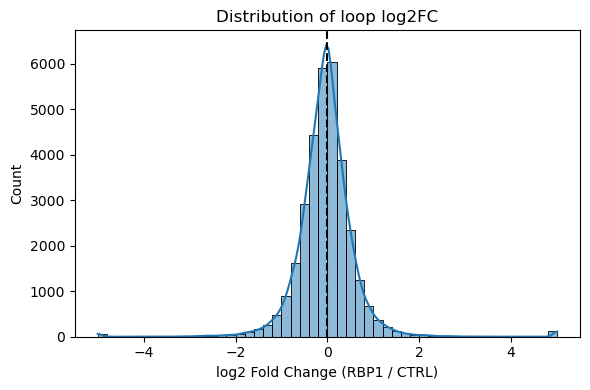

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.histplot(all_loops["log2FC_clipped"].dropna(), bins=50, kde=True)
plt.xlabel("log2 Fold Change (RBP1 / CTRL)")
plt.ylabel("Count")
plt.title("Distribution of loop log2FC")
plt.axvline(0, color="black", linestyle="--")
plt.tight_layout()
plt.show()

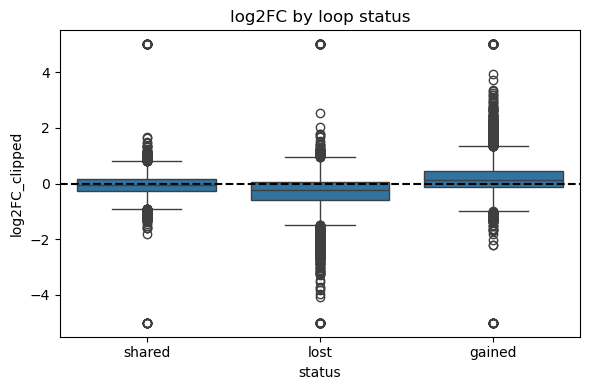

In [97]:
plt.figure(figsize=(6, 4))
sns.boxplot(data=all_loops, x="status", y="log2FC_clipped")
plt.axhline(0, color="black", linestyle="--")
plt.title("log2FC by loop status")
plt.tight_layout()
plt.show()

/tmp/ipykernel_960508/2294188906.py:2: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(data=all_loops, x="status", y="log2FC_clipped", inner="point", scale="width")


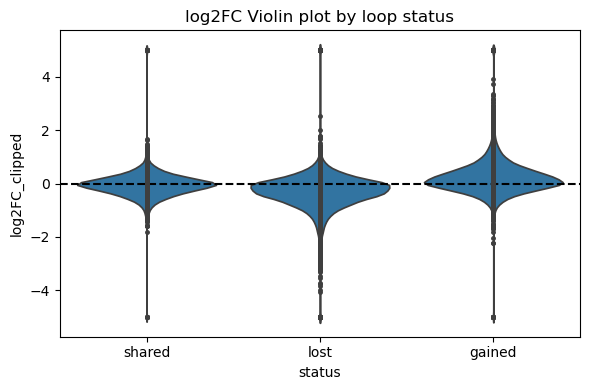

In [98]:
plt.figure(figsize=(6, 4))
sns.violinplot(data=all_loops, x="status", y="log2FC_clipped", inner="point", scale="width")
plt.axhline(0, color="black", linestyle="--")
plt.title("log2FC Violin plot by loop status")
plt.tight_layout()
plt.show()

In [99]:
shared_loops = all_loops[(all_loops["status"] == "shared") & all_loops["log2FC"].notna()]
upregulated = shared_loops[shared_loops["log2FC"] > 1]   #2 fold stronger in rbp1
downregulated = shared_loops[shared_loops["log2FC"] < -1] #2 fold weaker in rbp1

In [100]:
print(f"Upregulated shared loops: {len(upregulated)}")
print(f"Downregulated shared loops: {len(downregulated)}")

Upregulated shared loops: 52
Downregulated shared loops: 97


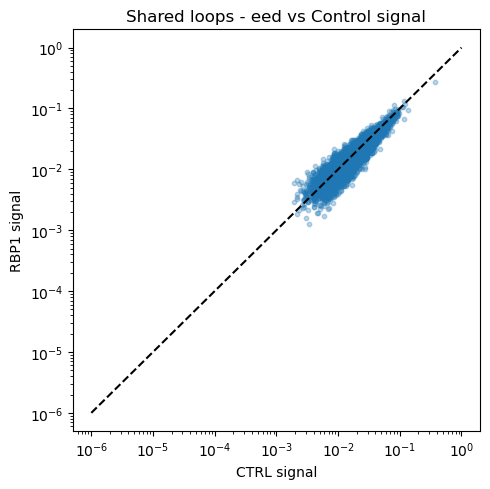

In [101]:
# signal shift

import matplotlib.pyplot as plt

plt.figure(figsize=(5, 5))
plt.scatter(
    shared_loops["ctrl_signal"],
    shared_loops["rbp1_signal"],
    alpha=0.3, s=10
)
plt.xscale("log")
plt.yscale("log")
plt.xlabel("CTRL signal")
plt.ylabel("RBP1 signal")
plt.plot([1e-6, 1], [1e-6, 1], ls="--", color="black")
plt.title("Shared loops - eed vs Control signal")
plt.tight_layout()
plt.show()


In [102]:
#shared loops stronger in control than eed. dampening

In [103]:
downregulated = shared_loops[shared_loops["log2FC"] < -1]
downregulated.describe()

,start1,end1,start2,end2,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped
count,9.700000e+01,9.700000e+01,9.700000e+01,9.700000e+01,97.000000,87.000000,97.000000,97.000000
mean,7.301482e+07,7.301982e+07,7.349137e+07,7.349637e+07,0.017262,0.005653,-2.639987,-1.566407
std,5.197794e+07,5.197794e+07,5.204114e+07,5.204114e+07,0.021871,0.003097,4.367835,1.179572
min,3.200000e+06,3.205000e+06,4.000000e+06,4.005000e+06,0.003376,0.001280,-17.521095,-5.000000
25%,3.118250e+07,3.118750e+07,3.162250e+07,3.162750e+07,0.008155,0.003483,-1.283111,-1.283111
50%,6.268250e+07,6.268750e+07,6.340250e+07,6.340750e+07,0.012295,0.005200,-1.153871,-1.153871
75%,1.041350e+08,1.041400e+08,1.046350e+08,1.046400e+08,0.017402,0.006961,-1.059365,-1.059365
max,2.334525e+08,2.334575e+08,2.340725e+08,2.340775e+08,0.188094,0.021398,-1.003412,-1.003412


In [104]:
downregulated[["chr1", "start1", "end1", "chr2", "start2", "end2"]] \
    .to_csv("downregulated.bedpe", sep="\t", index=False, header=False)

In [105]:
upregulated[["chr1", "start1", "end1", "chr2", "start2", "end2"]] \
    .to_csv("upregulated.bedpe", sep="\t", index=False, header=False)

In [106]:
# loading the merged loops file
h3k27_loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_ctrl.bedpe", sep="\t", header=None, names=["chr1", "start1", "end1", "chr2", "start2", "end2"])

In [107]:
overlap_h3k27_down = pd.merge(
    downregulated,
    h3k27_loops,
    on=["chr1", "start1", "end1", "chr2", "start2", "end2"]
)

In [108]:
overlap_h3k27_down

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped
0,chr14,104135000,104140000,chr14,104635000,104640000,shared,0.019926,NaN,-14.282365,-5.000000
1,chr15,92390000,92395000,chr15,92710000,92715000,shared,0.013463,0.005344,-1.332962,-1.332962
2,chr2,99815000,99820000,chr2,100250000,100255000,shared,0.007220,0.003553,-1.022990,-1.022990
3,chr20,37562500,37567500,chr20,38222500,38227500,shared,0.016216,0.007897,-1.037935,-1.037935
4,chr3,10755000,10760000,chr3,11060000,11065000,shared,0.009826,0.003919,-1.325976,-1.325976
5,chr3,127250000,127255000,chr3,127455000,127460000,shared,0.017402,0.007150,-1.283111,-1.283111
6,chr9,129642500,129647500,chr9,129782500,129787500,shared,0.053881,NaN,-15.717478,-5.000000


In [109]:
overlap_h3k27_down.describe()

,start1,end1,start2,end2,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped
count,7.000000e+00,7.000000e+00,7.000000e+00,7.000000e+00,7.000000,5.000000,7.000000,7.000000
mean,8.593571e+07,8.594071e+07,8.630214e+07,8.630714e+07,0.019705,0.005573,-5.143260,-2.286139
std,4.504584e+07,4.504584e+07,4.496078e+07,4.496078e+07,0.015695,0.001921,6.747326,1.858322
min,1.075500e+07,1.076000e+07,1.106000e+07,1.106500e+07,0.007220,0.003553,-15.717478,-5.000000
25%,6.497625e+07,6.498125e+07,6.546625e+07,6.547125e+07,0.011644,0.003919,-7.807664,-3.166481
50%,9.981500e+07,9.982000e+07,1.002500e+08,1.002550e+08,0.016216,0.005344,-1.325976,-1.325976
75%,1.156925e+08,1.156975e+08,1.160450e+08,1.160500e+08,0.018664,0.007150,-1.160523,-1.160523
max,1.296425e+08,1.296475e+08,1.297825e+08,1.297875e+08,0.053881,0.007897,-1.022990,-1.022990


In [110]:
# Ensure columns are of consistent type
downregulated[["start1", "end1", "start2", "end2"]] = downregulated[["start1", "end1", "start2", "end2"]].astype(int)
h3k27_loops[["start1", "end1", "start2", "end2"]] = h3k27_loops[["start1", "end1", "start2", "end2"]].astype(int)

# Create tuple sets for exact loop identity
polycomb_coords = set(tuple(x) for x in h3k27_loops[["chr1", "start1", "end1", "chr2", "start2", "end2"]].values)
down_coords = set(tuple(x) for x in downregulated[["chr1", "start1", "end1", "chr2", "start2", "end2"]].values)

# Intersect and count
polycomb_downregulated = down_coords & polycomb_coords
print(f"Polycomb-associated downregulated loops: {len(polycomb_downregulated)}")


Polycomb-associated downregulated loops: 7


/tmp/ipykernel_960508/2833355484.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downregulated[["start1", "end1", "start2", "end2"]] = downregulated[["start1", "end1", "start2", "end2"]].astype(int)


In [111]:
pct_downregulated_polycomb = 22 / 271
pct_total_polycomb = len(h3k27_loops) / len(all_loops)

enrichment = pct_downregulated_polycomb / pct_total_polycomb
enrichment

2.2149391908120264

/tmp/ipykernel_960508/702710022.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  downregulated["H3K27me3"] = downregulated.apply(


Text(0.5, 1.0, 'Shared Downregulated Loops: Polycomb vs Other')

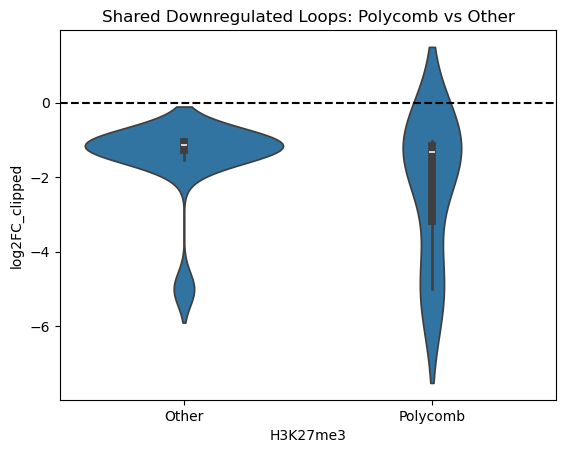

In [112]:
downregulated["H3K27me3"] = downregulated.apply(
    lambda row: "Polycomb" if ((row["chr1"], row["start1"], row["end1"],
                                row["chr2"], row["start2"], row["end2"])
                               in set(tuple(x) for x in h3k27_loops[["chr1","start1","end1","chr2","start2","end2"]].values))
    else "Other",
    axis=1
)

sns.violinplot(data=downregulated, x="H3K27me3", y="log2FC_clipped")
plt.axhline(0, ls="--", color="black")
plt.title("Shared Downregulated Loops: Polycomb vs Other")

In [113]:
h3k27_bed = pybedtools.BedTool("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/merged_loops_3tools/h3k27me3_associated_loops_eitheranchoroverlap_ctrl.bedpe").sort()

In [114]:
downreg_bed = pybedtools.BedTool("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/downregulated.bedpe").sort()

In [115]:
h3k27_shared = h3k27_bed.pair_to_pair(downreg_bed, type='either', slop=5000, is_sorted=False)
h3k27_shared.count()

22

In [116]:
all_loops.to_csv("all_loops_signal_log2fc.csv", index=False)

In [117]:
all_loops.to_csv("all_loops_signal_log2fc.bedpe", index=False)

In [118]:
all_loops[all_loops['status'] == 'gained']

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped
19036,chr1,3910000,3915000,chr1,4065000,4070000,gained,0.011669,0.009422,-0.308475,-0.308475
19037,chr1,3910000,3915000,chr1,4155000,4160000,gained,0.006800,0.008353,0.296743,0.296743
19038,chr1,5502500,5507500,chr1,5732500,5737500,gained,0.006607,0.007699,0.220712,0.220712
19039,chr1,5632500,5637500,chr1,5752500,5757500,gained,0.019869,0.020835,0.068512,0.068512
19040,chr1,6710000,6715000,chr1,7140000,7145000,gained,0.003147,0.004354,0.468141,0.468141
...,...,...,...,...,...,...,...,...,...,...,...
32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,0.061177,0.061177
32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,-0.570544,-0.570544
32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,0.005836,0.005836
32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,0.502513,0.502513


In [119]:
all_loops[all_loops['status'] == 'shared']

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped
0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,0.000000,0.000000
1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,0.000000,0.000000
2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,0.000000,0.000000
3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000
4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
7449,chrY,10992500,10997500,chrY,11722500,11727500,shared,0.003073,0.003080,0.003200,0.003200
7450,chrY,11002500,11007500,chrY,11292500,11297500,shared,0.006270,0.005309,-0.239941,-0.239941
7451,chrY,11522500,11527500,chrY,11712500,11717500,shared,0.006805,0.006980,0.036644,0.036644
7452,chrY,11525000,11530000,chrY,11680000,11685000,shared,0.011736,0.011248,-0.061234,-0.061234


In [120]:
all_loops[all_loops['status'] == 'lost']

,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,log2FC,log2FC_clipped
7454,chr1,3912500,3917500,chr1,4592500,4597500,lost,0.007892,0.005784,-0.448297,-0.448297
7455,chr1,5502500,5507500,chr1,5742500,5747500,lost,0.010166,0.010624,0.063582,0.063582
7456,chr1,5632500,5637500,chr1,5742500,5747500,lost,0.041111,0.032700,-0.330216,-0.330216
7457,chr1,5635000,5640000,chr1,5980000,5985000,lost,0.003995,0.000672,-2.571504,-2.571504
7458,chr1,6555000,6560000,chr1,6645000,6650000,lost,0.022830,0.020908,-0.126866,-0.126866
...,...,...,...,...,...,...,...,...,...,...,...
19031,chrX,114462500,114467500,chrX,114602500,114607500,lost,0.017679,0.015506,-0.189163,-0.189163
19032,chrX,132022500,132027500,chrX,132212500,132217500,lost,0.016384,0.011293,-0.536848,-0.536848
19033,chrY,10820000,10825000,chrY,11290000,11295000,lost,0.003529,0.002356,-0.582759,-0.582759
19034,chrY,11302500,11307500,chrY,11722500,11727500,lost,0.001016,0.000684,-0.571213,-0.571213


In [121]:
print(len(shared_df))     # Shared
print(len(ctrl_lost))     # Lost
print(len(rbp1_gained))   # Gained

print(len(shared_df) + len(ctrl_lost) + len(rbp1_gained))


7454
11582
13241
32277


In [122]:
import pybedtools

# Split anchors from downregulated loops
anchor1 = downregulated[["chr1", "start1", "end1"]].copy()
anchor1.columns = ["chrom", "start", "end"]
anchor1["loop_id"] = downregulated.index

anchor2 = downregulated[["chr2", "start2", "end2"]].copy()
anchor2.columns = ["chrom", "start", "end"]
anchor2["loop_id"] = downregulated.index

anchors = pd.concat([anchor1, anchor2])
anchors_bed = pybedtools.BedTool.from_dataframe(anchors)


In [123]:
peaks_bed = pybedtools.BedTool("/usr/users/papantonis1/aman/microc_data/cut_n_tag/nadine_cut_tag/nadine_cut_tag/C_H3K27me3_Spi_results/peakCalling/C_H3K27me3_Spi_seacr_top0.01.peaks.stringent.bed")

In [124]:
#overlap = anchors_bed.intersect(peaks_bed, u=True)
overlap = anchors_bed.intersect(peaks_bed.slop(b=0, genome="hg38"), u=True)
overlap_df = overlap.to_dataframe(names=["chrom", "start", "end", "loop_id"])

In [125]:
n_polycomb_loops = overlap_df["loop_id"].nunique()
print(f"Downregulated shared loops with H3K27me3 at either anchor: {n_polycomb_loops}")

Downregulated shared loops with H3K27me3 at either anchor: 7


In [126]:
h3k27_loops

,chr1,start1,end1,chr2,start2,end2
0,chr1,3912500,3917500,chr1,4592500,4597500
1,chr1,5502500,5507500,chr1,5622500,5627500
2,chr1,5502500,5507500,chr1,5742500,5747500
3,chr1,7045000,7050000,chr1,7645000,7650000
4,chr1,11080000,11085000,chr1,11575000,11580000
...,...,...,...,...,...,...
1178,chr8,26672500,26677500,chr8,27202500,27207500
1179,chr8,139022500,139027500,chr8,139632500,139637500
1180,chr9,21252500,21257500,chr9,21452500,21457500
1181,chr9,135082500,135087500,chr9,135342500,135347500
